<h1 align="center"> Results </h1>

Import necessary libraries:

In [152]:
import sys
sys.path.append("..")

import pandas as pd
import os
import numpy as np
from scipy import stats
from scipy.stats import chisquare
import seaborn as sns
from matplotlib import pyplot as plt
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler
from pybiomart import Server

from src.optimise import capitalize_j, format_case_id

### Load Data

In [2]:
# Step 1: Load RNA-Seq data
df_rna = pd.read_csv("/home/kryan24/MRes_Ultrasound/data/rna_counts/RNA_counts_141024.csv", header=None, low_memory=False)
df_rna_transposed = df_rna.transpose()
new_header = df_rna_transposed.iloc[1]
df_rna_transposed = df_rna_transposed[2:]
df_rna_transposed.columns = new_header
df_rna_transposed.rename(columns=lambda x: x.strip(), inplace=True) # Trim whitespaces

# Step 3: Filter RNA data for 'ENSG' columns
rna_cols = df_rna_transposed.filter(like='ENSG')

# Step 4: Load and merge image data
df_images = pd.read_excel("/home/kryan24/MRes_Ultrasound/data/metadata/RNA_Sample_Linking2.xlsx")
df_images.rename(columns=lambda x: x.strip(), inplace=True) # Trim whitespaces
df_images['Sample ID'] = df_images['Sample ID'].str.replace(' ', '_')
df_images["SURGICAL"] = df_images["SURGICAL"].str.strip() # Remove whitespaces from SURGICAL

df_merged = pd.merge(df_images, df_rna_transposed, left_on="Sample ID", right_on="Geneid")

df_merged_copy = df_merged

# Step 5: Correct data quality issues
df_merged["Extraction site"] = df_merged["Extraction site"].str.strip()
df_merged["Extraction site"] = df_merged["Extraction site"].str.lower()

# Step 6: Read the CSV file into a DataFrame 
df_radiomics = pd.read_csv("/home/kryan24/MRes_Ultrasound/data/metadata/radiomics_clinical_Barcroft_12_01_23.csv", low_memory=False)
# Remove first 2 columns
df_radiomics.drop(df_radiomics.columns[[0, 1]], axis=1, inplace=True)

# Filter columns
df_radiomics = df_radiomics.drop(df_radiomics.iloc[:, 3907:3950], axis=1)
df_radiomics["MAHCINE_CORECCTED"] = df_radiomics["MAHCINE_CORECCTED"].str.strip() # Remove whitespaces from MAHCINE_CORECCTED

# Step 7: Match radiomics data to metadata and filter DataFrame
df_radiomics_meta = df_merged[["Extraction site", "SURGICAL", "CASE ID", "CASE ID2"]]

# Step 8: Merge DataFrames
df_merged2 = pd.merge(df_radiomics_meta, df_radiomics, left_on="CASE ID", right_on="ID")

# Step 9: Correct data quality issues
df_merged2 = df_merged2.drop(["ID"], axis=1)

# Step 10: Keep the same samples for RNA as radiomics data
case_id_list = df_merged2["CASE ID"].tolist()
mask = df_merged["CASE ID"].isin(case_id_list)
df_merged = df_merged[mask]

In [3]:
# Check length of both paired sample dataframes
print("Number of rows in paired radiomics samples:", df_merged2.shape[0])
print("Number of rows in paired RNA samples:", df_merged.shape[0])

Number of rows in paired radiomics samples: 36
Number of rows in paired RNA samples: 36


## Patient Demographics

In [4]:
# Step 6: Read the CSV file into a DataFrame 
df_radiomics = pd.read_csv("/home/kryan24/MRes_Ultrasound/data/metadata/radiomics_clinical_Barcroft_12_01_23.csv", low_memory=False)
# Remove first 2 columns
df_radiomics.drop(df_radiomics.columns[[0, 1]], axis=1, inplace=True)
# Filter columns
surg_placeholder = df_radiomics["SURGICAL"]
df_radiomics.drop(["SURGICAL"], axis=1, inplace=True)
df_radiomics["MAHCINE_CORECCTED"] = df_radiomics["MAHCINE_CORECCTED"].str.strip() # Remove whitespaces from MAHCINE_CORECCTED
df_radiomics.insert(0, "SURGICAL", surg_placeholder)
df_radiomics["SURGICAL"] = df_radiomics["SURGICAL"].str.strip() 
df_radiomics["SURGICAL"] = df_radiomics["SURGICAL"].replace(["B-NS", "B-NS -->THEATRE"], "B-S")
df_radiomics["SURGICAL"] = df_radiomics["SURGICAL"].replace(["M-NS"], "M-S")
df_radiomics["ID"] = df_radiomics["ID"].astype(str)
df_radiomics = df_radiomics.rename({"ID": "CASE ID"}, axis=1)
df_radiomics["CASE ID"] = df_radiomics["CASE ID"].astype("int64")


df_radiomics_meta_id = df_radiomics_meta[["CASE ID", "CASE ID2"]]

# Merge CASE ID2 
df_radiomics_corr = pd.merge(df_radiomics, df_radiomics_meta_id, how="left", on="CASE ID")
id_placeholder = df_radiomics_corr["CASE ID2"]
df_radiomics_corr.drop(["CASE ID2"], axis=1, inplace=True)
df_radiomics_corr.insert(2, "CASE ID2", id_placeholder)

In [5]:
df_radiomics_meta_id.loc[df_radiomics_meta_id["CASE ID"] == 28376]

,CASE ID,CASE ID2
37,28376,J623
38,28376,J613


In [6]:
df_radiomics_corr

,SURGICAL,CASE ID,CASE ID2,N.voxels,SNS_vol,SNS_area,SNS_s2v,SNS_sph,SNS_sph_dis,SNS_com_1,...,SOLID.DIAMETER,PP,P.FLOW,IRREG,AS,ASCITES,COLOUR.SCORE,CYST,CRESCE,MAHCINE_CORECCTED
0,B-S,11935,NaN,144882.000000,144882.000000,291538.000000,2.012280,0.045859,21.830102,18.570425,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,VOLUSON E6
1,B-S,12041,NaN,197549.000000,197549.000000,398241.000000,2.016728,0.042007,24.042893,20.382207,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,VOLUSON E6
2,B-S,12165,NaN,107498.000000,107498.000000,216576.000000,2.014698,0.050482,19.808851,16.817131,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,VOLUSON E6
3,M-S,12287,NaN,155532.000000,155532.000000,312892.000000,2.011753,0.044707,22.369625,19.037510,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,VOLUSON E6
4,M-S,12665,NaN,53293.000000,53293.000000,107786.000000,2.022520,0.063540,15.738315,13.275361,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,VOLUSON S10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
573,B-S,756,NaN,233536.250000,233536.250000,469333.250000,2.009764,0.039234,25.538184,21.770426,...,0.0,0,NA,1.0,1.0,0.0,2.0,LOW LEVEL,0,SAMSUNG W10
574,B-S,757,NaN,171948.400000,171948.400000,345942.800000,2.012222,0.043817,22.981643,19.552589,...,0.0,0,NA,1.0,1.0,0.0,1.0,LOW LEVEL,1,SAMSUNG W10
575,B-S,759,NaN,130348.666667,130348.666667,262413.333333,2.013769,0.048313,20.913305,17.771700,...,0.0,0,NA,1.0,1.0,0.0,1.0,LOW LEVEL,1,SAMSUNG W10
576,M-S,760,NaN,76213.000000,76213.000000,153870.666667,2.019244,0.056766,17.658334,14.936394,...,25.0,0,0,1.0,0.0,0.0,1.0,LOW LEVEL,0,SAMSUNG W10


In [7]:
# Number of patients
print(f"Number patients (n):", df_radiomics_corr["CASE ID"].nunique())

Number patients (n): 577


In [8]:
image_directory = "/home/kryan24/MRes_Ultrasound/CLIPRNA/images_matched"
image_filenames = []
image_id_list = []
image_count = 0

for index, row in df_radiomics_corr.iterrows():

    # Format and capitalize the CASE IDs
    case_id = capitalize_j(format_case_id(row['CASE ID']))
    case_id2 = capitalize_j(format_case_id(row['CASE ID2']))

    for file_name in os.listdir(image_directory):
            if file_name.endswith('.nii.gz') and 'seg' not in file_name:
                file_name_corrected = capitalize_j(file_name)  # Capitalize 'j' in the filename

                # Check if either case_id or case_id2 is a substring of the filename
                # Only check if the ID is non-empty
                if (case_id and case_id in file_name_corrected):
                    image_filenames.append(file_name)
                    image_id_list.append(case_id)
                    image_count += 1

                if (case_id2 and case_id2 in file_name_corrected):
                    image_filenames.append(file_name)
                    image_id_list.append(case_id2)
                    image_count += 1


In [9]:
# Number of images
print(f"Number of Samples: ", image_count)

Number of Samples:  1390


In [10]:
# Create dataframe
images_dict = {"image_name": image_filenames, "ID": image_id_list}
images_df = pd.DataFrame(images_dict)
images_df

,image_name,ID
0,11935_6.nii.gz,11935
1,11935_3.nii.gz,11935
2,12165_2.nii.gz,12165
3,12287_4.nii.gz,12287
4,12287_5.nii.gz,12287
...,...,...
1385,J760_0015.nii.gz,760
1386,J765_0019.nii.gz,765
1387,J765_0020.nii.gz,765
1388,J765_0021.nii.gz,765


In [11]:
# Age: median (IQR) years
age = df_radiomics[["AGE"]]
age["AGE"] = pd.to_numeric(age["AGE"], errors="coerce")
age["AGE"] = age["AGE"].fillna(age["AGE"].median())
age

/tmp/ipykernel_82015/2925736154.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  age["AGE"] = pd.to_numeric(age["AGE"], errors="coerce")
/tmp/ipykernel_82015/2925736154.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  age["AGE"] = age["AGE"].fillna(age["AGE"].median())


,AGE
0,33.0
1,69.0
2,38.0
3,70.0
4,51.0
...,...
572,56.0
573,44.0
574,28.0
575,56.0


In [12]:
print(f"Age median: ", age.median())

Age median:  AGE    45.0
dtype: float64


In [13]:
# Calculate interquartile range of values in the 'points' column
q75, q25 = np.percentile(age["AGE"], [75 ,25])
print(f"Q1: ", q25)
print(f"Q3: ", q75)

Q1:  35.0
Q3:  59.0


In [14]:
# Calculate p-vale
t_stat, p_value = stats.ttest_1samp(age["AGE"], age.median())
print(f"P value: ", p_value)

P value:  5.472197714557139e-06


In [15]:
images_df

,image_name,ID
0,11935_6.nii.gz,11935
1,11935_3.nii.gz,11935
2,12165_2.nii.gz,12165
3,12287_4.nii.gz,12287
4,12287_5.nii.gz,12287
...,...,...
1385,J760_0015.nii.gz,760
1386,J765_0019.nii.gz,765
1387,J765_0020.nii.gz,765
1388,J765_0021.nii.gz,765


In [16]:
images_dup = images_df.pivot_table(index=["ID"], aggfunc="size")
images_dup = images_dup.reset_index()
images_dup = images_dup.rename({0: "Count"}, axis=1)
images_dup

,ID,Count
0,11935,2
1,12165,1
2,12287,2
3,12665,2
4,12666,2
...,...,...
433,756,8
434,757,5
435,760,3
436,765,4


In [17]:
images_df.loc[images_df["ID"] == "756"]

,image_name,ID
1370,J756_0004.nii.gz,756
1371,J756_0002.nii.gz,756
1372,J756_0019.nii.gz,756
1373,J756_0001.nii.gz,756
1374,J756_0010.nii.gz,756
1375,J756_0003.nii.gz,756
1376,J756_0020.nii.gz,756
1377,J756_0007.nii.gz,756


In [18]:
print(f"Images median: ", images_dup["Count"].median())

Images median:  2.0


In [19]:
# Calculate interquartile range of values
q75, q25 = np.percentile(images_dup["Count"], [75 ,25])
print(f"Q1: ", q25)
print(f"Q3: ", q75)

Q1:  2.0
Q3:  3.0


In [20]:
df_radiomics

,SURGICAL,CASE ID,N.voxels,SNS_vol,SNS_area,SNS_s2v,SNS_sph,SNS_sph_dis,SNS_com_1,SNS_com_2,...,SOLID.DIAMETER,PP,P.FLOW,IRREG,AS,ASCITES,COLOUR.SCORE,CYST,CRESCE,MAHCINE_CORECCTED
0,B-S,11935,144882.000000,144882.000000,291538.000000,2.012280,0.045859,21.830102,18.570425,0.000097,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,VOLUSON E6
1,B-S,12041,197549.000000,197549.000000,398241.000000,2.016728,0.042007,24.042893,20.382207,0.000076,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,VOLUSON E6
2,B-S,12165,107498.000000,107498.000000,216576.000000,2.014698,0.050482,19.808851,16.817131,0.000129,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,VOLUSON E6
3,M-S,12287,155532.000000,155532.000000,312892.000000,2.011753,0.044707,22.369625,19.037510,0.000089,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,VOLUSON E6
4,M-S,12665,53293.000000,53293.000000,107786.000000,2.022520,0.063540,15.738315,13.275361,0.000257,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,VOLUSON S10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
572,B-S,756,233536.250000,233536.250000,469333.250000,2.009764,0.039234,25.538184,21.770426,0.000061,...,0.0,0,NA,1.0,1.0,0.0,2.0,LOW LEVEL,0,SAMSUNG W10
573,B-S,757,171948.400000,171948.400000,345942.800000,2.012222,0.043817,22.981643,19.552589,0.000086,...,0.0,0,NA,1.0,1.0,0.0,1.0,LOW LEVEL,1,SAMSUNG W10
574,B-S,759,130348.666667,130348.666667,262413.333333,2.013769,0.048313,20.913305,17.771700,0.000117,...,0.0,0,NA,1.0,1.0,0.0,1.0,LOW LEVEL,1,SAMSUNG W10
575,M-S,760,76213.000000,76213.000000,153870.666667,2.019244,0.056766,17.658334,14.936394,0.000184,...,25.0,0,0,1.0,0.0,0.0,1.0,LOW LEVEL,0,SAMSUNG W10


In [21]:
# Diagnosis
df_radiomics["SURGICAL"].value_counts()

SURGICAL
B-S    444
M-S    132
NS       1
Name: count, dtype: int64

In [22]:
flag = df_radiomics.loc[df_radiomics["SURGICAL"] == "NS"]
flag[["HISTOLOGY"]]

,HISTOLOGY
11,?Benign


In [23]:
df_radiomics["SURGICAL"] = df_radiomics["SURGICAL"].replace(["NS"], "B-S")

In [24]:
# Diagnosis
df_radiomics["SURGICAL"].value_counts()

SURGICAL
B-S    445
M-S    132
Name: count, dtype: int64

In [25]:
ans = chisquare(f_obs = df_radiomics["SURGICAL"].value_counts())
ans

Power_divergenceResult(statistic=169.79029462738302, pvalue=8.221828134269592e-39)

In [26]:
# Diagnosis
df_radiomics["HISTOLOGY"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 577 entries, 0 to 576
Series name: HISTOLOGY
Non-Null Count  Dtype 
--------------  ----- 
470 non-null    object
dtypes: object(1)
memory usage: 4.6+ KB


In [27]:
df_radiomics["HISTOLOGY"].value_counts()

HISTOLOGY
NA                         180
BENIGN                      86
MALIGNANT                   66
Benign                      48
BORDERLINE                  27
Borderline                  15
Malignant                   13
BENIGN                      11
Benign                      10
MALIGNANT                    4
Malignnat                    2
Malignant                    1
malignant                    1
Borderline                   1
?Benign                      1
TBC                          1
MALIGNANT - NON OVARIAN      1
TBC                          1
BENIGN                       1
Name: count, dtype: int64

In [28]:
df_radiomics["HISTOLOGY"] = df_radiomics["HISTOLOGY"].str.strip() 
df_radiomics["HISTOLOGY"] = df_radiomics["HISTOLOGY"].replace(["BENIGN", "MALIGNANT", "Benign", "BORDERLINE", "Borderline", "Malignant", "Malignnat", "malignant", "MALIGNANT - NON OVARIAN"], "Yes")
df_radiomics["HISTOLOGY"] = df_radiomics["HISTOLOGY"].replace(["NA", "?Benign", "TBC"], "No")

In [29]:
df_radiomics["HISTOLOGY"].value_counts()

HISTOLOGY
Yes    287
No     183
Name: count, dtype: int64

In [30]:
df_radiomics["HISTOLOGY"] = df_radiomics["HISTOLOGY"].fillna("No")

In [31]:
df_radiomics["HISTOLOGY"].value_counts()

HISTOLOGY
No     290
Yes    287
Name: count, dtype: int64

In [32]:
ans = chisquare(f_obs = df_radiomics["HISTOLOGY"].value_counts())
ans

Power_divergenceResult(statistic=0.01559792027729636, pvalue=0.9006093415061255)

In [33]:
# RNA-seq
rna_array = []
rna_array = ["Yes"] * 29
rna_array_no = ["No"] * 548
rna_array += rna_array_no

In [34]:
len(rna_array)

577

In [35]:
rna_dict = {"count": rna_array}
rna_df = pd.DataFrame(rna_dict)
rna_df

,count
0,Yes
1,Yes
2,Yes
3,Yes
4,Yes
...,...
572,No
573,No
574,No
575,No


In [36]:
rna_df["count"].value_counts()

count
No     548
Yes     29
Name: count, dtype: int64

In [37]:
ans = chisquare(f_obs = rna_df["count"].value_counts())
ans

Power_divergenceResult(statistic=466.8301559792028, pvalue=1.5687540909725514e-103)

In [38]:
# CA-125
df_radiomics[["CA125"]]

,CA125
0,NaN
1,13
2,N
3,288
4,272
...,...
572,11
573,N
574,N
575,225


In [39]:
ca125 = df_radiomics[["CA125"]]
ca125["CA125"] = pd.to_numeric(ca125["CA125"], errors="coerce")
ca125["CA125"] = ca125["CA125"].fillna(ca125["CA125"].median())
ca125

/tmp/ipykernel_82015/1974174491.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ca125["CA125"] = pd.to_numeric(ca125["CA125"], errors="coerce")
/tmp/ipykernel_82015/1974174491.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ca125["CA125"] = ca125["CA125"].fillna(ca125["CA125"].median())


,CA125
0,25.0
1,13.0
2,25.0
3,288.0
4,272.0
...,...
572,11.0
573,25.0
574,25.0
575,225.0


In [40]:
print(f"CA125 median: ", ca125["CA125"].median())

CA125 median:  25.0


In [41]:
# Calculate interquartile range of values
q75, q25 = np.percentile(ca125["CA125"], [75 ,25])
print(f"Q1: ", q25)
print(f"Q3: ", q75)

Q1:  23.0
Q3:  26.0


In [42]:
# Calculate p-vale
t_stat, p_value = stats.ttest_1samp(ca125["CA125"], ca125.median())
print(f"P value: ", p_value)

P value:  0.006344620668292865


## Correlation Heatmaps

In [43]:
# Filter radiomics data 
rad_cols = df_merged2.drop(["Extraction site", "SURGICAL", "CASE ID", "CASE ID2", "MAHCINE_CORECCTED"], axis=1)

# Step 1: Prepare image filenames and filter data
image_directory = "/home/kryan24/MRes_Ultrasound/CLIPRNA/images_matched"
image_filenames_rna = []
image_filenames_rad = []
rna_data_filtered = []
rad_data_filtered = []
surgical_rna = []
surgical_rad = []
sample_count_rna = 0 
sample_count_rad = 0 

rna_paired_id_list = []
rad_paired_id_list = [] 

In [44]:
for index, row in df_merged.iterrows():

    # Format and capitalize the CASE IDs
    case_id = capitalize_j(format_case_id(row['CASE ID']))
    case_id2 = capitalize_j(format_case_id(row['CASE ID2']))

    for file_name in os.listdir(image_directory):
            if file_name.endswith('.nii.gz') and 'seg' not in file_name:
                file_name_corrected = capitalize_j(file_name)  # Capitalize 'j' in the filename

                # Check if either case_id or case_id2 is a substring of the filename
                # Only check if the ID is non-empty
                if (case_id and case_id in file_name_corrected):
                    image_filenames_rna.append(file_name)
                    rna_data_filtered.append(
                        row[rna_cols.columns].apply(pd.to_numeric, errors='coerce').fillna(0)
                    )
                    surgical_rna.append(row["SURGICAL"])
                    rna_paired_id_list.append(case_id)
                    sample_count_rna += 1
                    break  # Only use the first matching image for each row

                if (case_id2 and case_id2 in file_name_corrected):
                    image_filenames_rna.append(file_name)
                    rna_data_filtered.append(
                        row[rna_cols.columns].apply(pd.to_numeric, errors='coerce').fillna(0)
                    )
                    surgical_rna.append(row["SURGICAL"])
                    rna_paired_id_list.append(case_id2)
                    sample_count_rna += 1
                    break  # Only use the first matching image for each row

print(f"Number of Samples: ", sample_count_rna)

Number of Samples:  29


In [45]:
for index, row in df_merged2.iterrows():

    # Format and capitalize the CASE IDs
    case_id = capitalize_j(format_case_id(row['CASE ID']))
    case_id2 = capitalize_j(format_case_id(row['CASE ID2']))

    for file_name in os.listdir(image_directory):
            if file_name.endswith('.nii.gz') and 'seg' not in file_name:
                file_name_corrected = capitalize_j(file_name)  # Capitalize 'j' in the filename

                # Check if either case_id or case_id2 is a substring of the filename
                # Only check if the ID is non-empty
                if (case_id and case_id in file_name_corrected):
                    image_filenames_rad.append(file_name)
                    rad_data_filtered.append(
                        row[rad_cols.columns].apply(pd.to_numeric, errors='coerce').fillna(0)
                    )
                    surgical_rad.append(row["SURGICAL"])
                    rad_paired_id_list.append(case_id)
                    sample_count_rad += 1
                    break  # Only use the first matching image for each row

                if (case_id2 and case_id2 in file_name_corrected):
                    image_filenames_rad.append(file_name)
                    rad_data_filtered.append(
                        row[rad_cols.columns].apply(pd.to_numeric, errors='coerce').fillna(0)
                    )
                    surgical_rad.append(row["SURGICAL"])
                    rad_paired_id_list.append(case_id2)
                    sample_count_rad += 1
                    break  # Only use the first matching image for each row

print(f"Number of Samples: ", sample_count_rad)

Number of Samples:  29


In [46]:
flag = (surgical_rna == surgical_rad)
print(f"Matching Diagnoses: ", flag)

flag2 = (image_filenames_rna == image_filenames_rad)
print(f"Matching Images: ", flag2)

flag3 = (rna_paired_id_list == rad_paired_id_list)
print(f"Matching IDs: ", flag3)

Matching Diagnoses:  True
Matching Images:  True
Matching IDs:  True


### Radiomics

In [47]:
# Convert to DataFrame
rad_data_filtered = pd.DataFrame(rad_data_filtered)

In [48]:
# Scale radiomics sample counts
scaler_rad = StandardScaler()
rad_data_df = pd.DataFrame(rad_data_filtered)
rad_data_df = pd.DataFrame(scaler_rad.fit_transform(rad_data_df), columns=rad_data_filtered.columns)
rad_data_df.insert(0, "SURGICAL", surgical_rna)
rad_data_df

,SURGICAL,N.voxels,SNS_vol,SNS_area,SNS_s2v,SNS_sph,SNS_sph_dis,SNS_com_1,SNS_com_2,SNS_max3d,...,GLCM_sumVar_HHH_256gl,GLCM_sumEnt_HHH_256gl,GLCM_difVar_HHH_256gl,GLCM_difEnt_HHH_256gl,GLCM_AutoCorrel_HHH_256gl,GLCM_ClTend_HHH_256gl,GLCM_Homoge1_HHH_256gl,GLCM_IDMN_HHH_256gl,GLCM_IDN_HHH_256gl,GLCM_invVar_HHH_256gl
0,B-S,0.417175,0.417175,0.428241,0.343961,-0.588136,0.567023,0.521469,-0.483596,-0.191924,...,-0.548623,-0.050934,-0.394866,-0.110254,-1.138279,-0.548623,-0.210251,0.507891,0.418556,0.367162
1,M-S,-0.237828,-0.237828,-0.230058,0.466507,-0.078978,-0.079799,-0.112677,-0.193879,-0.195513,...,-0.108096,-0.121246,0.026993,-0.155170,1.360933,-0.108096,0.086234,0.053855,0.233059,0.502252
2,M-S,-0.488926,-0.488926,-0.483197,0.435608,0.084470,-0.311708,-0.335802,-0.114387,-1.139294,...,0.943623,1.092322,-0.008166,0.936308,-1.664474,0.943623,-1.129742,-0.586652,-1.149292,-0.968319
3,M-S,0.518815,0.518815,0.516114,-0.514965,-0.621151,0.616790,0.628451,-0.499231,0.303292,...,-0.534427,-0.102078,-0.817081,-0.329948,-1.772811,-0.534427,-0.220673,0.775797,0.582267,0.321584
4,M-S,-0.657198,-0.657198,-0.664023,-0.536711,0.505407,-0.651341,-0.606934,0.249158,-0.813636,...,-0.350833,-0.150510,-0.455640,-0.217572,-1.252471,-0.350833,0.303727,0.495151,0.435804,-0.059436
5,M-S,-0.531239,-0.531239,-0.528920,0.241239,0.170079,-0.389391,-0.397848,-0.049779,-0.697906,...,0.325531,0.454854,0.592770,0.443070,-1.345047,0.325531,-0.481805,-0.385036,-0.321501,0.000968
6,M-S,0.844067,0.844067,0.871039,1.107679,-0.807259,0.928415,0.819882,-0.578105,0.532957,...,-0.633723,-0.171703,-0.428690,-0.073392,-0.569513,-0.633723,0.237121,0.494668,0.394093,0.080949
7,B-S,0.164592,0.164592,0.174413,0.416721,-0.422071,0.336549,0.294155,-0.398009,-0.217044,...,-0.758019,-0.290765,-0.679527,-0.216917,0.410355,-0.758019,0.600336,0.692482,0.542349,-0.128892
8,M-S,0.334117,0.334117,0.322663,-1.055089,-0.448802,0.401307,0.453872,-0.402161,-0.342642,...,0.189110,0.623449,0.085154,0.603130,0.496380,0.189110,-0.708678,-0.230132,-0.504687,-0.458132
9,B-S,-1.217520,-1.217520,-1.224817,-0.546155,1.001439,-1.247128,-1.190191,0.531495,-1.440730,...,1.437889,0.985668,1.208710,0.933755,-1.607977,1.437889,-0.864012,-1.182263,-1.068034,-0.570135


In [49]:
thresholds = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

def spearman_thresh_function(features, target, thresholds):
    threshold_list = []
    num_features = []

    column_names = features.columns.tolist()

    for threshold in thresholds:
        threshold_list.append(threshold)
        count = 0
        for column in column_names:
            corr, pval = spearmanr(features[column], target)
            if (corr != 0.9):
                if (corr >= threshold and corr <= threshold+1):
                    count += 1
            else:
                if (corr >= threshold):
                    count += 1
        num_features.append(count)

    return threshold_list, num_features

In [50]:
def spearman_df_function(features, target, threshold):
    feature_names = []
    feature_correlations = []
    
    column_names = features.columns.tolist()

    for column in column_names:
        corr, pval = spearmanr(features[column], target)
        if (corr >= threshold):
            feature_names.append(column)
            feature_correlations.append(corr)

    return feature_names, feature_correlations

In [51]:
# Filter features selected using Spearman Rho
rad_all = rad_data_df.drop(["SURGICAL"], axis=1)
rad_class_cat = pd.Categorical(rad_data_df["SURGICAL"].astype("category")).codes

In [52]:
rad_thresholds, rad_threshold_counts = spearman_thresh_function(rad_all, rad_class_cat, thresholds)

/tmp/ipykernel_82015/673404981.py:13: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, pval = spearmanr(features[column], target)


In [53]:
threshold_df = pd.DataFrame(
    {
        "Threshold": map(str, rad_thresholds),
        "Feature Count": rad_threshold_counts
    }
)

threshold_df

,Threshold,Feature Count
0,0,2511
1,0.1,1280
2,0.2,444
3,0.3,140
4,0.4,14
5,0.5,0
6,0.6,0
7,0.7,0
8,0.8,0
9,0.9,0


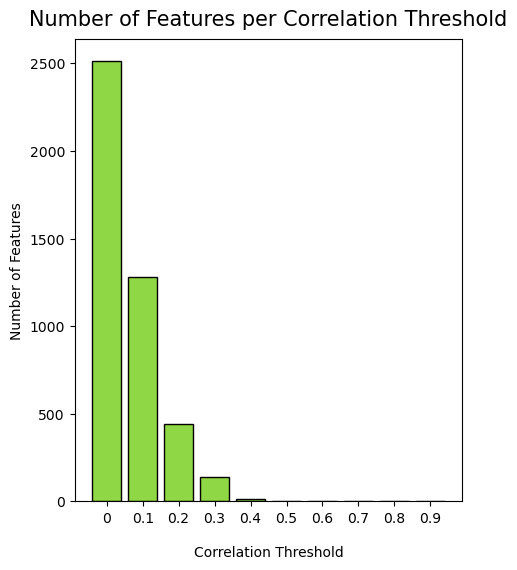

In [54]:
fig,ax = plt.subplots(figsize=(5, 6)) 
ax.bar(threshold_df["Threshold"], threshold_df["Feature Count"], color="#8FD744FF", edgecolor="black")
ax.set_title("Number of Features per Correlation Threshold", fontsize = 15, pad=10)
ax.set_xlabel("Correlation Threshold", fontsize=10, labelpad=15)
ax.set_ylabel("Number of Features", fontsize=10)
plt.show()

In [57]:
rad_feature_names, rad_feature_correlations = spearman_df_function(rad_all, rad_class_cat, 0.37)

/tmp/ipykernel_82015/2827494689.py:8: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, pval = spearmanr(features[column], target)


In [58]:
spearman_df = pd.DataFrame(
    {
        "Features": rad_feature_names,
        "Correlations": rad_feature_correlations
    }
)

spearman_df

,Features,Correlations
0,GLCM_Varian_8gl,0.417153
1,GLCM_ClProm_8gl,0.437502
2,GLCM_sumVar_8gl,0.406978
3,GLCM_ClTend_8gl,0.406978
4,GLCM_ClProm_16gl,0.396804
5,GLCM_ClProm_32gl,0.396804
6,GLCM_ClProm_64gl,0.396804
7,GLCM_ClProm_128gl,0.396804
8,GLCM_ClProm_256gl,0.396804
9,FOS_Entr_LLL_8gl,0.376455


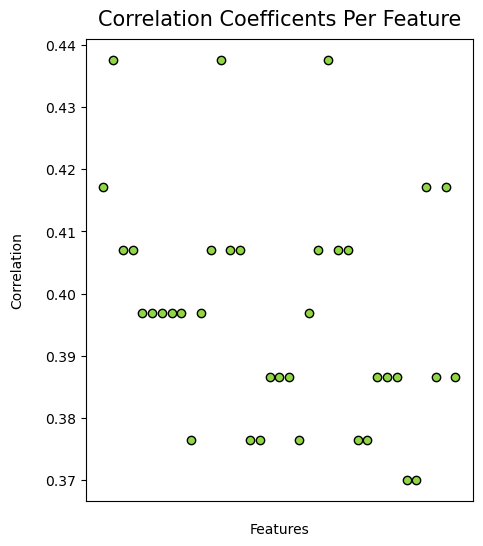

In [59]:
fig,ax = plt.subplots(figsize=(5, 6)) 
ax.scatter(spearman_df["Features"], spearman_df["Correlations"], color="#8FD744FF", edgecolors="black")
ax.set_title("Correlation Coefficents Per Feature", fontsize = 15, pad=10)
ax.set_xlabel("Features", fontsize=10, labelpad=15)
ax.set_ylabel("Correlation", fontsize=10, labelpad=15)

plt.tick_params(bottom=False, labelbottom=False)
plt.show()

In [60]:
# Store spearman features
spearman_rad = spearman_df["Features"].to_list()

# Seperating out the features
rad_spear = rad_data_df.drop(["SURGICAL"], axis=1)
# Only keep the top features
rad_spear = rad_spear.loc[:, rad_spear.columns.isin(spearman_rad)]
# Seperating out the target
rad_class = rad_data_df[["SURGICAL"]]

In [61]:
rad_spear

,GLCM_Varian_8gl,GLCM_ClProm_8gl,GLCM_sumVar_8gl,GLCM_ClTend_8gl,GLCM_ClProm_16gl,GLCM_ClProm_32gl,GLCM_ClProm_64gl,GLCM_ClProm_128gl,GLCM_ClProm_256gl,FOS_Entr_LLL_8gl,...,GLCM_ClProm_LLH_32gl,GLCM_ClProm_LLH_64gl,GLCM_ClProm_LLH_128gl,GLCM_ClProm_LLH_256gl,FD_max_LHL_4gl,FD_max_LHH_4gl,GLSZM_SzNonUnif_HHL_8gl,GLSZM_LzoneHiGl_HHL_8gl,GLSZM_SzNonUnif_HHH_8gl,GLSZM_LzoneHiGl_HHH_8gl
0,0.041790,-0.316471,0.056274,0.056274,-0.106618,-0.116070,-0.094950,-0.087672,-0.092360,-0.308129,...,-0.018061,-0.012261,-0.010430,-0.011251,0.188982,0.188982,-0.030790,-0.718091,-0.030790,-0.718091
1,0.212875,-0.326971,0.212613,0.212613,-0.355017,-0.378450,-0.383676,-0.382983,-0.382559,0.019488,...,-0.412305,-0.425761,-0.423281,-0.425233,0.188982,0.188982,-0.214735,-0.634718,-0.214735,-0.634718
2,-0.292040,-0.344128,-0.288321,-0.288321,-0.332372,-0.340150,-0.339055,-0.333303,-0.334275,0.322638,...,-0.341714,-0.337744,-0.335022,-0.336482,0.188982,0.188982,1.355006,0.411571,1.355006,0.411571
3,0.307938,0.195863,0.337907,0.337907,0.178321,0.163957,0.167286,0.177114,0.170196,0.151799,...,0.378865,0.379781,0.383344,0.381601,0.188982,0.188982,-0.068456,0.020677,-0.068456,0.020677
4,0.693899,2.414991,0.680812,0.680812,2.526189,2.547210,2.571450,2.567432,2.562487,0.149538,...,2.517637,2.496387,2.488163,2.486673,0.188982,0.188982,-1.046247,-0.528852,-1.046247,-0.528852
5,1.508066,0.883041,1.483895,1.483895,0.942632,0.914312,0.941057,0.948556,0.937388,1.238467,...,0.967739,0.969890,0.973378,0.971366,0.188982,0.188982,-0.705275,-0.771456,-0.705275,-0.771456
6,0.092924,-0.578465,0.085276,0.085276,-0.560940,-0.565875,-0.566553,-0.569538,-0.573079,0.529835,...,-0.713440,-0.712091,-0.711817,-0.711318,0.188982,0.188982,-0.327879,-0.548757,-0.327879,-0.548757
7,-0.884013,-0.604106,-0.867118,-0.867118,-0.575443,-0.581018,-0.587166,-0.587510,-0.589247,-0.863289,...,-0.726831,-0.737663,-0.742120,-0.740595,0.188982,0.188982,-0.618312,-0.585560,-0.618312,-0.585560
8,0.068296,-0.281658,0.032569,0.032569,-0.263031,-0.267474,-0.265315,-0.274471,-0.267668,0.605795,...,-0.426381,-0.425908,-0.426975,-0.427010,0.188982,0.188982,0.203876,0.885916,0.203876,0.885916
9,-0.367515,-0.973269,-0.426190,-0.426190,-0.976209,-0.967117,-0.972186,-0.973652,-0.972528,0.489389,...,-0.993828,-0.994993,-0.994365,-0.994481,0.188982,0.188982,-1.034832,-0.555424,-1.034832,-0.555424


In [66]:
rad_spear_corr = rad_spear.corr(numeric_only=True)
rad_spear_corr

,GLCM_Varian_8gl,GLCM_ClProm_8gl,GLCM_sumVar_8gl,GLCM_ClTend_8gl,GLCM_ClProm_16gl,GLCM_ClProm_32gl,GLCM_ClProm_64gl,GLCM_ClProm_128gl,GLCM_ClProm_256gl,FOS_Entr_LLL_8gl,...,GLCM_ClProm_LLH_32gl,GLCM_ClProm_LLH_64gl,GLCM_ClProm_LLH_128gl,GLCM_ClProm_LLH_256gl,FD_max_LHL_4gl,FD_max_LHH_4gl,GLSZM_SzNonUnif_HHL_8gl,GLSZM_LzoneHiGl_HHL_8gl,GLSZM_SzNonUnif_HHH_8gl,GLSZM_LzoneHiGl_HHH_8gl
GLCM_Varian_8gl,1.000000,0.847532,0.999615,0.999615,0.843583,0.843653,0.840781,0.841518,0.841603,0.867271,...,0.831348,0.832650,0.834290,0.833850,0.264524,0.264524,0.244121,0.012755,0.244121,0.012755
GLCM_ClProm_8gl,0.847532,1.000000,0.854061,0.854061,0.997609,0.998192,0.997681,0.997591,0.997779,0.572810,...,0.992900,0.993129,0.993228,0.993254,0.231520,0.231520,0.158026,0.042201,0.158026,0.042201
GLCM_sumVar_8gl,0.999615,0.854061,1.000000,1.000000,0.849453,0.849636,0.846679,0.847408,0.847532,0.857063,...,0.837500,0.838886,0.840487,0.840076,0.268355,0.268355,0.240507,0.009248,0.240507,0.009248
GLCM_ClTend_8gl,0.999615,0.854061,1.000000,1.000000,0.849453,0.849636,0.846679,0.847408,0.847532,0.857063,...,0.837500,0.838886,0.840487,0.840076,0.268355,0.268355,0.240507,0.009248,0.240507,0.009248
GLCM_ClProm_16gl,0.843583,0.997609,0.849453,0.849453,1.000000,0.999689,0.999704,0.999673,0.999729,0.570647,...,0.994986,0.994997,0.995052,0.995093,0.230522,0.230522,0.142287,0.033961,0.142287,0.033961
GLCM_ClProm_32gl,0.843653,0.998192,0.849636,0.849636,0.999689,1.000000,0.999852,0.999823,0.999906,0.570408,...,0.994769,0.994879,0.994943,0.994956,0.228052,0.228052,0.144463,0.034203,0.144463,0.034203
GLCM_ClProm_64gl,0.840781,0.997681,0.846679,0.846679,0.999704,0.999852,1.000000,0.999988,0.999986,0.568243,...,0.995570,0.995629,0.995658,0.995684,0.229127,0.229127,0.142171,0.029247,0.142171,0.029247
GLCM_ClProm_128gl,0.841518,0.997591,0.847408,0.847408,0.999673,0.999823,0.999988,1.000000,0.999982,0.569128,...,0.995713,0.995778,0.995817,0.995838,0.229317,0.229317,0.142890,0.028314,0.142890,0.028314
GLCM_ClProm_256gl,0.841603,0.997779,0.847532,0.847532,0.999729,0.999906,0.999986,0.999982,1.000000,0.568640,...,0.995432,0.995515,0.995558,0.995580,0.228970,0.228970,0.143101,0.030146,0.143101,0.030146
FOS_Entr_LLL_8gl,0.867271,0.572810,0.857063,0.857063,0.570647,0.570408,0.568243,0.569128,0.568640,1.000000,...,0.558791,0.559512,0.561775,0.561036,0.237521,0.237521,0.347153,0.084827,0.347153,0.084827


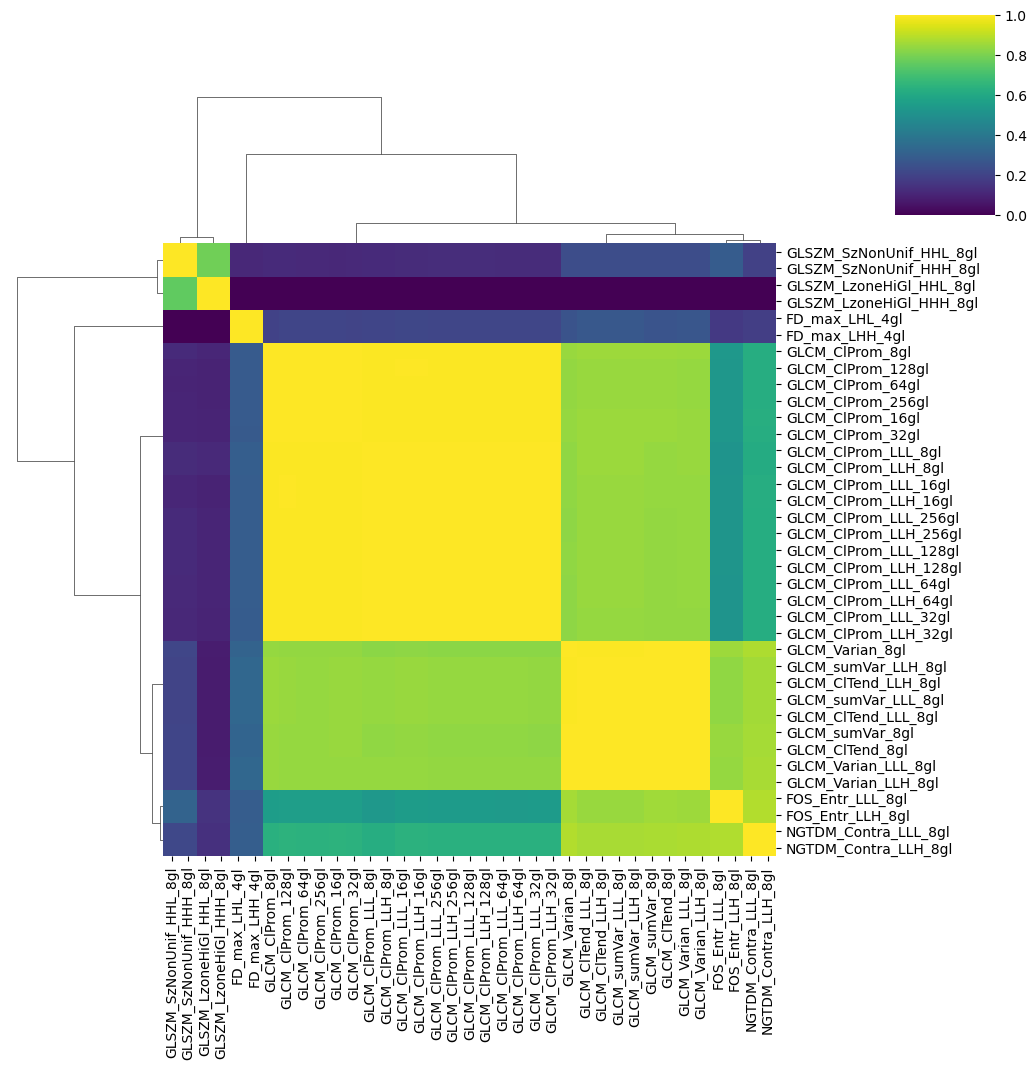

In [132]:
kws = dict(cbar_kws=dict(ticks=[0, 0.2, 0.4, 0.6, 0.8, 1], orientation='vertical'), figsize=(6, 6))

g = sns.clustermap(rad_spear_corr,
                    metric="correlation", 
                    standard_scale=1, 
                    cmap="viridis", 
                    cbar_pos=(0.9, 0.8, .03, .4)) 

x0, _y0, _w, _h = g.cbar_pos
g.ax_cbar.set_position([0.9, 0.86, 0.1, 0.2])
plt.show()

### RNA

In [133]:
# Convert to DataFrame
rna_data_filtered = pd.DataFrame(rna_data_filtered)

In [134]:
# Scale rnaiomics sample counts
scaler_rna = StandardScaler()
rna_data_df = pd.DataFrame(rna_data_filtered)
rna_data_df = pd.DataFrame(scaler_rna.fit_transform(rna_data_df), columns=rna_data_filtered.columns)
rna_data_df.insert(0, "SURGICAL", surgical_rna)
rna_data_df

1,SURGICAL,ENSG00000279928,ENSG00000228037,ENSG00000142611,ENSG00000284616,ENSG00000157911,ENSG00000260972,ENSG00000224340,ENSG00000226374,ENSG00000229280,...,ENSG00000198886,ENSG00000210176,ENSG00000210184,ENSG00000210191,ENSG00000198786,ENSG00000198695,ENSG00000210194,ENSG00000198727,ENSG00000210195,ENSG00000210196
0,B-S,-0.522657,-0.560751,0.101272,0.0,0.801661,-0.188982,0.0,-0.241649,0.0,...,-0.703429,-0.4,-0.188982,-0.480762,-0.915940,-0.853969,-0.313789,-0.308376,0.0,-0.769143
1,M-S,-0.522657,-0.193550,-0.410009,0.0,0.998039,-0.188982,0.0,-0.241649,0.0,...,-0.296584,-0.4,-0.188982,1.510966,-0.281915,-0.109122,-0.111569,-0.489692,0.0,-0.038702
2,M-S,-0.522657,-0.280979,-0.088972,0.0,-0.199113,-0.188982,0.0,-0.241649,0.0,...,-0.605208,-0.4,-0.188982,1.510966,0.038930,0.058338,0.292870,-0.216130,0.0,-0.830291
3,M-S,2.725285,-0.385893,-0.267326,0.0,-0.301079,5.291503,0.0,-0.241649,0.0,...,0.434776,2.5,-0.188982,-0.480762,2.350608,1.529340,1.506187,0.661752,0.0,1.647318
4,M-S,2.183961,-0.298464,-1.170986,0.0,-0.180230,-0.188982,0.0,-0.241649,0.0,...,-0.838850,2.5,5.291503,1.510966,0.355180,0.137433,0.090650,-0.661607,0.0,0.498290
5,M-S,-0.522657,0.418453,0.243955,0.0,-1.588866,-0.188982,0.0,-0.241649,0.0,...,-0.590207,-0.4,-0.188982,-0.480762,-0.722198,-0.374449,-0.516008,-0.501867,0.0,-0.927016
6,M-S,-0.522657,4.370241,-0.243545,0.0,1.062239,-0.188982,0.0,-0.241649,0.0,...,-0.516199,-0.4,-0.188982,-0.480762,-0.707910,-1.269436,-1.324887,-0.696806,0.0,-0.852527
7,B-S,-0.522657,-0.368407,1.064384,0.0,0.299386,-0.188982,0.0,-0.241649,0.0,...,-0.988383,-0.4,-0.188982,-0.480762,-0.748743,-0.283768,-0.313789,-0.756174,0.0,-0.689651
8,M-S,-0.522657,-0.595723,-1.075864,0.0,0.960274,-0.188982,0.0,-0.241649,0.0,...,-0.469459,-0.4,-0.188982,-0.480762,-0.184959,-0.355558,0.495089,-0.504609,0.0,-0.331656
9,B-S,-0.522657,-0.385893,-0.005740,0.0,-0.565434,-0.188982,0.0,-0.241649,0.0,...,-0.877138,-0.4,-0.188982,-0.480762,0.443789,0.888800,0.495089,-0.631381,0.0,-0.833071


In [135]:
# Filter features selected using Spearman Rho
rna_all = rna_data_df.drop(["SURGICAL"], axis=1)
rna_class_cat = pd.Categorical(rna_data_df["SURGICAL"].astype("category")).codes

In [136]:
rna_thresholds, rna_threshold_counts = spearman_thresh_function(rna_all, rna_class_cat, thresholds)

/tmp/ipykernel_82015/673404981.py:13: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, pval = spearmanr(features[column], target)


In [137]:
threshold_df = pd.DataFrame(
    {
        "Threshold": map(str, rna_thresholds),
        "Feature Count": rna_threshold_counts
    }
)

threshold_df

,Threshold,Feature Count
0,0,30102
1,0.1,21120
2,0.2,12900
3,0.3,6784
4,0.4,3274
5,0.5,1088
6,0.6,127
7,0.7,1
8,0.8,0
9,0.9,0


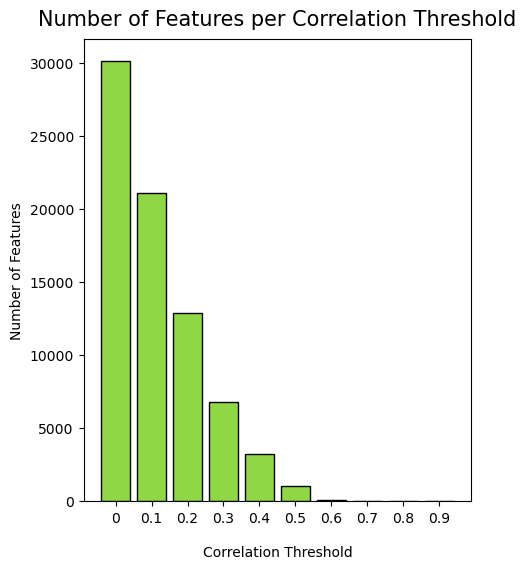

In [138]:
fig,ax = plt.subplots(figsize=(5, 6)) 
ax.bar(threshold_df["Threshold"], threshold_df["Feature Count"], color="#8FD744FF", edgecolor="black")
ax.set_title("Number of Features per Correlation Threshold", fontsize = 15, pad=10)
ax.set_xlabel("Correlation Threshold", fontsize=10, labelpad=15)
ax.set_ylabel("Number of Features", fontsize=10)
plt.show()

In [145]:
rna_feature_names, rna_feature_correlations = spearman_df_function(rna_all, rna_class_cat, 0.64)

/tmp/ipykernel_82015/2827494689.py:8: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, pval = spearmanr(features[column], target)


In [146]:
spearman_df = pd.DataFrame(
    {
        "Features": rna_feature_names,
        "Correlations": rna_feature_correlations
    }
)

spearman_df

,Features,Correlations
0,ENSG00000158710,0.640991
1,ENSG00000197622,0.671514
2,ENSG00000142224,0.648479
3,ENSG00000085999,0.666674
4,ENSG00000065911,0.640991
5,ENSG00000138074,0.661340
6,ENSG00000206113,0.642020
7,ENSG00000281398,0.646238
8,ENSG00000281357,0.704035
9,ENSG00000213585,0.640991


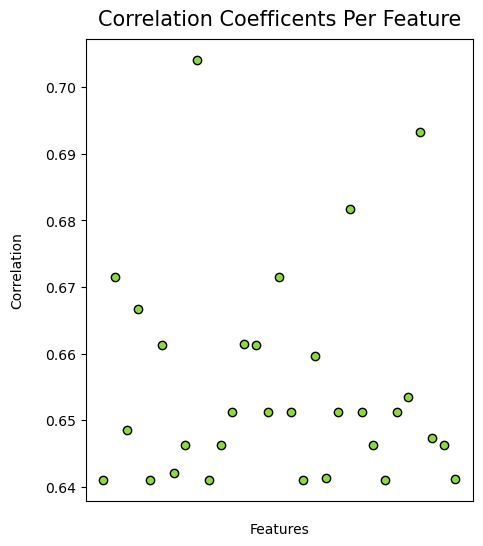

In [147]:
fig,ax = plt.subplots(figsize=(5, 6)) 
ax.scatter(spearman_df["Features"], spearman_df["Correlations"], color="#8FD744FF", edgecolors="black")
ax.set_title("Correlation Coefficents Per Feature", fontsize = 15, pad=10)
ax.set_xlabel("Features", fontsize=10, labelpad=15)
ax.set_ylabel("Correlation", fontsize=10, labelpad=15)

plt.tick_params(bottom=False, labelbottom=False)
plt.show()

In [148]:
# Store spearman features
spearman_rna = spearman_df["Features"].to_list()

# Seperating out the features
rna_spear = rna_data_df.drop(["SURGICAL"], axis=1)
# Only keep the top features
rna_spear = rna_spear.loc[:, rna_spear.columns.isin(spearman_rna)]
# Seperating out the target
rna_class = rna_data_df[["SURGICAL"]]

In [149]:
rna_spear

1,ENSG00000158710,ENSG00000197622,ENSG00000142224,ENSG00000085999,ENSG00000065911,ENSG00000138074,ENSG00000206113,ENSG00000281398,ENSG00000281357,ENSG00000213585,...,ENSG00000198604,ENSG00000181026,ENSG00000258947,ENSG00000129667,ENSG00000267278,ENSG00000235313,ENSG00000267174,ENSG00000105048,ENSG00000242114,ENSG00000099958
0,-1.490319,-1.562942,-0.340304,-0.597147,-0.825115,-1.032343,-0.534407,-0.798448,-1.224677,-1.070845,...,-1.578954,-1.084154,-0.760003,-0.897289,-0.693138,-0.783741,-0.876138,-0.599487,-0.852950,-0.397497
1,2.308980,-0.505795,-0.289126,1.599035,0.971951,2.523267,-0.470480,3.260692,2.287129,1.654619,...,0.125456,0.867184,-0.350006,1.375072,0.056694,-0.094999,0.182529,1.363359,-0.255563,0.087771
2,-0.761854,0.167371,-0.306185,-0.518337,-0.303802,-0.318886,-0.370023,-0.701101,-0.297030,-0.431756,...,-0.519664,0.176504,-0.549464,-0.748099,-0.610588,-0.408064,-0.315667,-0.597675,-0.535588,-0.342561
3,-0.413623,0.222568,5.050433,-0.281906,-0.528758,-0.326669,-0.141711,0.709298,-0.098248,-0.686484,...,0.414913,1.403635,2.686183,0.112526,0.063573,2.785196,-0.564765,-0.259816,-0.479583,-0.237267
4,-0.156086,1.189719,-0.237948,-0.308176,0.697531,1.344117,-0.333493,0.523659,-0.562072,2.448679,...,0.715148,0.100507,-0.338925,1.250376,-0.610588,-0.032386,-0.564765,-0.306011,2.245993,2.234855
5,0.432985,1.504104,-0.033236,-0.518337,-0.231971,-0.366882,-0.525275,-0.606018,-0.297030,-0.571256,...,0.590435,-0.105132,-0.305682,0.869608,0.283708,-0.220225,-0.440216,-0.555405,-0.031543,4.647463
6,0.716832,0.394159,-0.280596,1.493955,1.368097,1.402491,1.328617,0.172758,-0.495811,0.211334,...,1.795993,0.227914,-0.228115,1.322744,-0.555554,-0.032386,-0.564765,2.055986,0.472502,-0.296781
7,-0.972589,-0.846578,-0.340304,-0.607655,-0.821244,-0.763824,-0.534407,-0.755434,-0.827114,-0.962018,...,-1.040071,-0.699698,-0.826489,-1.034231,-0.968306,-0.783741,-0.813863,-0.597675,-0.908955,-0.310515
8,0.285116,0.823738,-0.314715,-0.323938,-0.064222,0.166265,-0.333493,-0.610545,1.160701,0.832819,...,-0.357999,1.680801,-0.183791,-0.307210,-0.177199,-0.595902,-0.689314,-0.597675,0.883205,-0.278469
9,-0.838255,-1.020569,-0.340304,-0.591893,-0.717153,-0.928568,-0.543540,-0.798448,-1.357198,-1.006296,...,-0.878406,-1.316616,-0.726760,-1.008624,-0.885756,-0.595902,-0.813863,-0.598279,-0.815613,-0.388341


In [153]:
# Connect to Biomart server
server = Server(host="http://www.ensembl.org")

In [154]:
# List available marts
server.list_marts()

,name,display_name
0,ENSEMBL_MART_ENSEMBL,Ensembl Genes 113
1,ENSEMBL_MART_MOUSE,Mouse strains 113
2,ENSEMBL_MART_SEQUENCE,Sequence
3,ENSEMBL_MART_ONTOLOGY,Ontology
4,ENSEMBL_MART_GENOMIC,Genomic features 113
5,ENSEMBL_MART_SNP,Ensembl Variation 113
6,ENSEMBL_MART_FUNCGEN,Ensembl Regulation 113


In [155]:
# Retrieving a ensembl genes mart
mart = server["ENSEMBL_MART_ENSEMBL"]

In [156]:
# List available datasets
mart.list_datasets()

,name,display_name
0,apolyacanthus_gene_ensembl,Spiny chromis genes (ASM210954v1)
1,cpbellii_gene_ensembl,Painted turtle genes (Chrysemys_picta_bellii-3...
2,choffmanni_gene_ensembl,Sloth genes (choHof1)
3,bsplendens_gene_ensembl,Siamese fighting fish genes (fBetSpl5.2)
4,sdumerili_gene_ensembl,Greater amberjack genes (Sdu_1.0)
...,...,...
209,pmuralis_gene_ensembl,Common wall lizard genes (PodMur_1.0)
210,anancymaae_gene_ensembl,Ma's night monkey genes (Anan_2.0)
211,csavignyi_gene_ensembl,C.savignyi genes (CSAV 2.0)
212,easinus_gene_ensembl,Donkey genes (ASM1607732v2)


In [157]:
# Select homosapiens dataset
dataset = mart["hsapiens_gene_ensembl"]

In [158]:
# Find out what attributes there are in the dataset 
dataset.list_attributes()

,name,display_name,description
0,ensembl_gene_id,Gene stable ID,Stable ID of the Gene
1,ensembl_gene_id_version,Gene stable ID version,Versionned stable ID of the Gene
2,ensembl_transcript_id,Transcript stable ID,Stable ID of the Transcript
3,ensembl_transcript_id_version,Transcript stable ID version,Versionned stable ID of the Transcript
4,ensembl_peptide_id,Protein stable ID,
...,...,...,...
3191,sequence_genomic_coding_end,Genomic coding end,
3192,sequence_constitutive,,
3193,cds_length,CDS Length,
3194,cds_start,CDS start,


In [159]:
# Retrieve the gene stable IDS and gene names from biomart
biomart_df = dataset.query(attributes=["ensembl_gene_id", "external_gene_name"])
biomart_df.head()

,Gene stable ID,Gene name
0,ENSG00000210049,MT-TF
1,ENSG00000211459,MT-RNR1
2,ENSG00000210077,MT-TV
3,ENSG00000210082,MT-RNR2
4,ENSG00000209082,MT-TL1


In [160]:
# Convert biomart_df to dictionary 
biomart_map = biomart_df.set_index("Gene name")
dict_genes = biomart_map["Gene stable ID"].to_dict()

# Convert ensmbl IDS to gene names
ensembl_ids_list = list(rna_spear.columns)
gene_names = {v:k for k, v in dict_genes.items()}
genes_correct = [gene_names.get(item, item)  for item in ensembl_ids_list]

In [161]:
# Rename columns for RNA counts dataframe
rna_spear.columns = genes_correct
rna_spear.head()

,TAGLN2,CDC42SE1,IL19,RAD54L,MTHFD2,SLC5A6,CFAP99,SNHG4,ARRDC3-AS1,VDAC1,...,BAZ1A,AEN,TUBB3,RHBDF2,MAP3K14-AS1,HM13-IT1,ENSG00000267174,TNNT1,MTFP1,ENSG00000099958
0,-1.490319,-1.562942,-0.340304,-0.597147,-0.825115,-1.032343,-0.534407,-0.798448,-1.224677,-1.070845,...,-1.578954,-1.084154,-0.760003,-0.897289,-0.693138,-0.783741,-0.876138,-0.599487,-0.852950,-0.397497
1,2.308980,-0.505795,-0.289126,1.599035,0.971951,2.523267,-0.470480,3.260692,2.287129,1.654619,...,0.125456,0.867184,-0.350006,1.375072,0.056694,-0.094999,0.182529,1.363359,-0.255563,0.087771
2,-0.761854,0.167371,-0.306185,-0.518337,-0.303802,-0.318886,-0.370023,-0.701101,-0.297030,-0.431756,...,-0.519664,0.176504,-0.549464,-0.748099,-0.610588,-0.408064,-0.315667,-0.597675,-0.535588,-0.342561
3,-0.413623,0.222568,5.050433,-0.281906,-0.528758,-0.326669,-0.141711,0.709298,-0.098248,-0.686484,...,0.414913,1.403635,2.686183,0.112526,0.063573,2.785196,-0.564765,-0.259816,-0.479583,-0.237267
4,-0.156086,1.189719,-0.237948,-0.308176,0.697531,1.344117,-0.333493,0.523659,-0.562072,2.448679,...,0.715148,0.100507,-0.338925,1.250376,-0.610588,-0.032386,-0.564765,-0.306011,2.245993,2.234855


In [162]:
rna_spear_corr = rna_spear.corr(numeric_only=True)
rna_spear_corr

,TAGLN2,CDC42SE1,IL19,RAD54L,MTHFD2,SLC5A6,CFAP99,SNHG4,ARRDC3-AS1,VDAC1,...,BAZ1A,AEN,TUBB3,RHBDF2,MAP3K14-AS1,HM13-IT1,ENSG00000267174,TNNT1,MTFP1,ENSG00000099958
TAGLN2,1.000000,0.338394,-0.018407,0.378880,0.547408,0.473843,0.231920,0.591447,0.487568,0.703727,...,0.568878,0.351249,0.150528,0.742489,0.445428,-0.002029,0.438615,0.728763,0.504236,0.158262
CDC42SE1,0.338394,1.000000,0.138986,0.117901,0.325428,0.397709,0.154663,0.323863,0.526097,0.350424,...,0.759906,0.650561,0.311053,0.452036,0.471912,0.031069,0.313994,0.040589,0.405116,0.386665
IL19,-0.018407,0.138986,1.000000,-0.062418,-0.110770,0.017181,-0.034977,0.227972,0.052999,-0.135113,...,0.214861,0.321246,0.638008,0.032165,0.136295,0.599454,0.116515,-0.066277,-0.075537,-0.015176
RAD54L,0.378880,0.117901,-0.062418,1.000000,0.844365,0.743750,-0.011951,0.391238,0.094354,0.425658,...,0.252817,0.011729,0.364291,0.308114,0.117250,-0.014813,-0.060410,0.539848,0.370053,-0.023959
MTHFD2,0.547408,0.325428,-0.110770,0.844365,1.000000,0.715438,0.126013,0.543949,0.225485,0.731167,...,0.502284,0.078949,0.246722,0.594964,0.267109,-0.060339,0.058945,0.640488,0.489395,0.118007
SLC5A6,0.473843,0.397709,0.017181,0.743750,0.715438,1.000000,0.117040,0.701627,0.443671,0.614897,...,0.573145,0.395362,0.400447,0.433921,0.359527,0.051852,0.312890,0.427399,0.499964,0.138882
CFAP99,0.231920,0.154663,-0.034977,-0.011951,0.126013,0.117040,1.000000,0.166874,0.455339,0.175846,...,0.348161,0.448537,0.014290,0.279176,0.513917,0.094097,0.328759,0.427645,0.191797,-0.107513
SNHG4,0.591447,0.323863,0.227972,0.391238,0.543949,0.701627,0.166874,1.000000,0.647588,0.606069,...,0.608695,0.366329,0.230980,0.534115,0.431908,0.207625,0.459206,0.422342,0.150105,0.031851
ARRDC3-AS1,0.487568,0.526097,0.052999,0.094354,0.225485,0.443671,0.455339,0.647588,1.000000,0.404862,...,0.581736,0.759343,0.150993,0.425023,0.545590,0.114843,0.478518,0.194631,0.215760,-0.047160
VDAC1,0.703727,0.350424,-0.135113,0.425658,0.731167,0.614897,0.175846,0.606069,0.404862,1.000000,...,0.470698,0.270918,0.017186,0.669114,0.290225,-0.043420,0.223286,0.597390,0.586508,0.207216


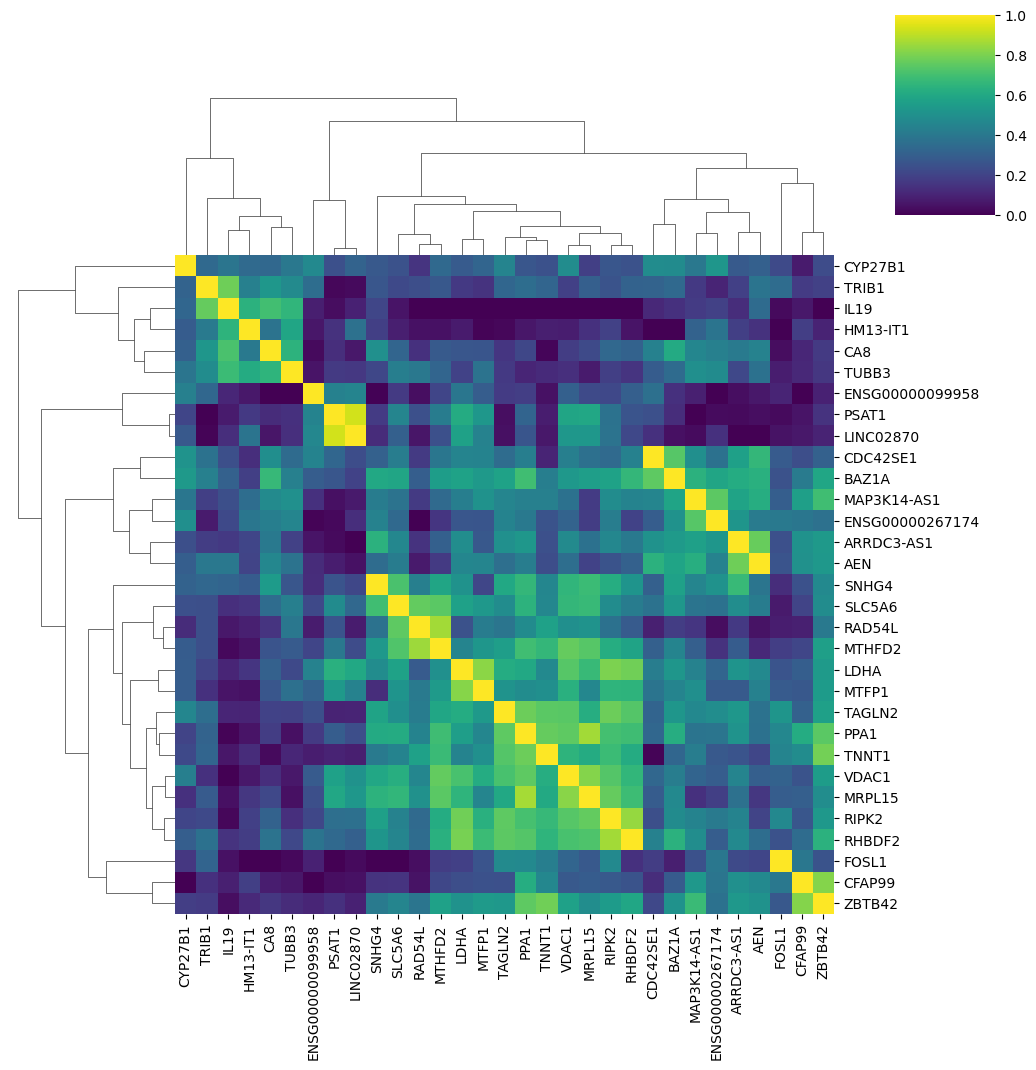

In [163]:
kws = dict(cbar_kws=dict(ticks=[0, 0.2, 0.4, 0.6, 0.8, 1], orientation='vertical'), figsize=(6, 6))

g = sns.clustermap(rna_spear_corr,
                    metric="correlation", 
                    standard_scale=1, 
                    cmap="viridis", 
                    cbar_pos=(0.9, 0.8, .03, .4)) 

x0, _y0, _w, _h = g.cbar_pos
g.ax_cbar.set_position([0.9, 0.86, 0.1, 0.2])
plt.show()